In [1]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

## Connect and get data

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

# Step 1: get first commit per user per lab
# Step 2: join with deadlines, calculate diff
# Step 3: avg diff per user + count pageviews
test = pd.io.sql.read_sql(
    """
    SELECT
        fc.uid,
        AVG((d.deadlines - strftime('%s', fc.first_commit)) / 3600.0) AS avg_diff,
        COUNT(DISTINCT p.datetime) AS pageviews
    FROM (
        SELECT uid, labname, MIN(timestamp) AS first_commit
        FROM checker
        WHERE uid LIKE 'user_%'
        AND status = 'ready'
        AND numTrials = 1
        AND labname IN ('laba04', 'laba04s', 'laba05', 'laba06', 'laba06s')
        GROUP BY uid, labname
    ) fc
    JOIN deadlines d ON fc.labname = d.labs
    JOIN pageviews p ON fc.uid = p.uid
    GROUP BY fc.uid
    """,
    conn
)

# Get num_commits per user
commits = pd.io.sql.read_sql(
    """
    SELECT uid, COUNT(*) AS num_commits
    FROM checker
    WHERE uid LIKE 'user_%'
    AND status = 'ready'
    AND labname != 'project1'
    GROUP BY uid
    """,
    conn
)

conn.close()

df = test.merge(commits, on='uid')
print(df.shape)
df.head()

(11, 4)


,uid,avg_diff,pageviews,num_commits
0,user_1,65.119778,28,35
1,user_10,75.242444,89,13
2,user_14,159.568796,143,33
3,user_17,62.207667,47,29
4,user_18,6.368148,3,4


## Plot scatter matrix

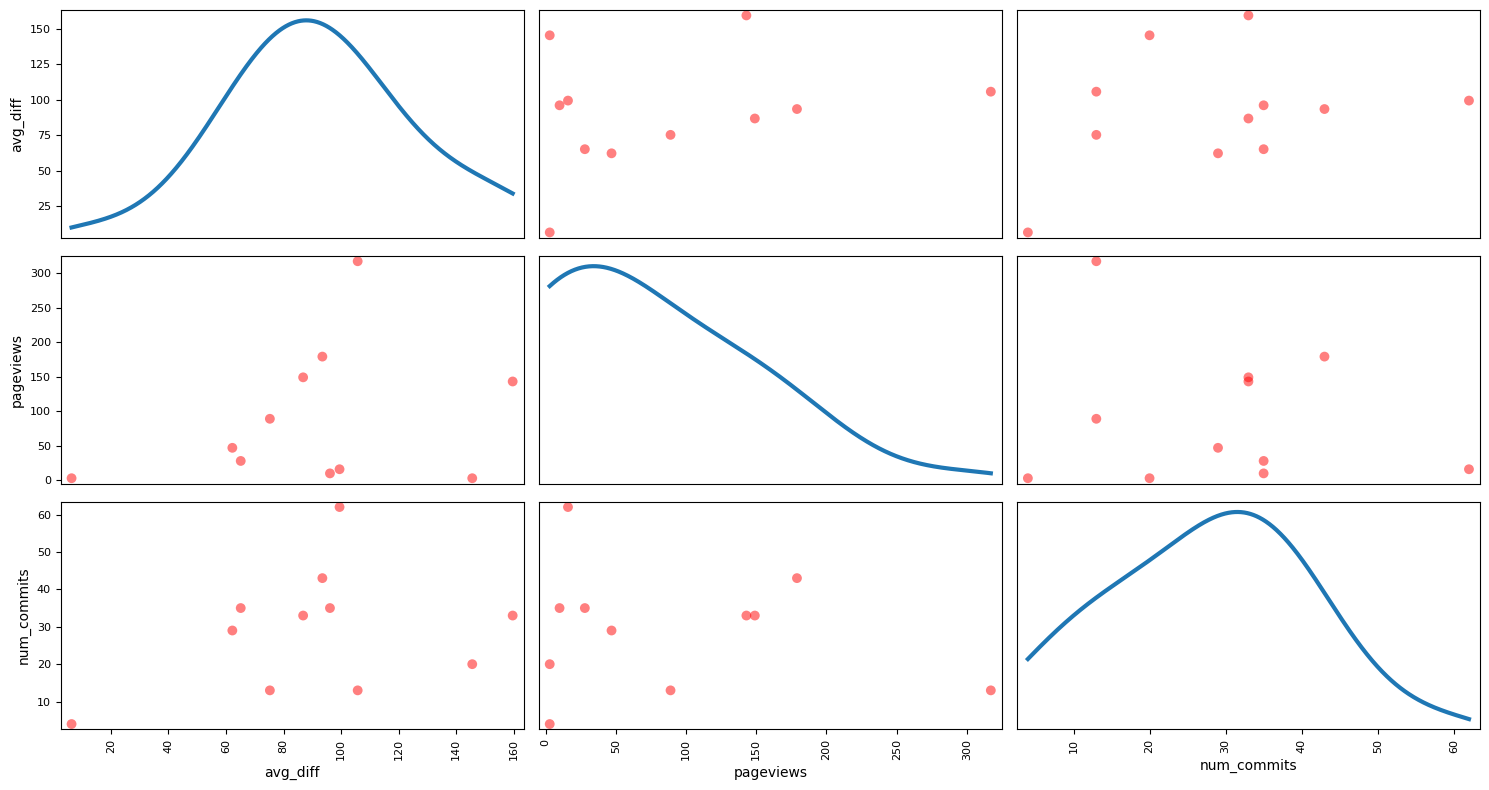

In [3]:
scatter_matrix(
    df[['avg_diff', 'pageviews', 'num_commits']],
    figsize=(15, 8),
    diagonal='kde',
    color='red',
    s=200,
    density_kwds={'linewidth': 3}
)

plt.tight_layout()
plt.show()

## Answer questions

In [5]:
corr = df[['avg_diff', 'pageviews', 'num_commits']].corr()
print('Correlation matrix:')
print(corr)
print()
print('Low pageviews → low commits?', corr.loc['pageviews','num_commits'] > 0)
print('Low pageviews → small avg_diff?', corr.loc['pageviews','avg_diff'] > 0)
print('Many users with low commits?', df['num_commits'].median() < df['num_commits'].mean())
print('Many users with small avg_diff?', df['avg_diff'].median() < df['avg_diff'].mean())

Correlation matrix:
             avg_diff  pageviews  num_commits
avg_diff     1.000000   0.279143     0.314364
pageviews    0.279143   1.000000    -0.140916
num_commits  0.314364  -0.140916     1.000000

Low pageviews → low commits? False
Low pageviews → small avg_diff? True
Many users with low commits? False
Many users with small avg_diff? False


Can we say that if a user has a low number of pageviews, then they likely have a low number of commits? The answer is yes or no: no.

Can we say that if a user has a low number of pageviews, then they likely have a small average difference between the first commit and the lab deadline? The answer is yes or no: yes.

Can we say that there are many users with a low number of commits and a few with a high number of commits? The answer is yes or no: no.

Can we say that there are many users with a small average difference and a few with a large average difference? The answer is yes or no: no.